In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


deformed_h_list[0]: 1
n: 1 elapsed: 0.038727736473083495
n: 2 elapsed: 0.03972183465957642
n: 3 elapsed: 0.039727318286895755
n: 4 elapsed: 0.0397820512453715
n: 5 elapsed: 0.039825721581776934
n: 6 elapsed: 0.04023528496424357
n: 7 elapsed: 0.04026141961415609
n: 8 elapsed: 0.04029763539632161
n: 9 elapsed: 0.04034053881963094
n: 10 elapsed: 0.04038696686426799
n: 11 elapsed: 0.04049543539683024
n: 12 elapsed: 0.040573803583780925
n: 13 elapsed: 0.040662566820780434
n: 14 elapsed: 0.04073816935221354
n: 15 elapsed: 0.0409052848815918
n: 16 elapsed: 0.04107242027918498
n: 17 elapsed: 0.04122267166773478
n: 18 elapsed: 0.04137783447901408
n: 19 elapsed: 0.04160658518473307
n: 20 elapsed: 0.04184156656265259
n: 21 elapsed: 0.04209167162577311
n: 22 elapsed: 0.04239056905110677
n: 23 elapsed: 0.04272201855977376
n: 24 elapsed: 0.043105137348175046
n: 25 elapsed: 0.04340928395589193
n: 26 elapsed: 0.04380768537521362
n: 27 elapsed: 0.04417210022608439
n: 28 elapsed: 0.044826666514078774
n:

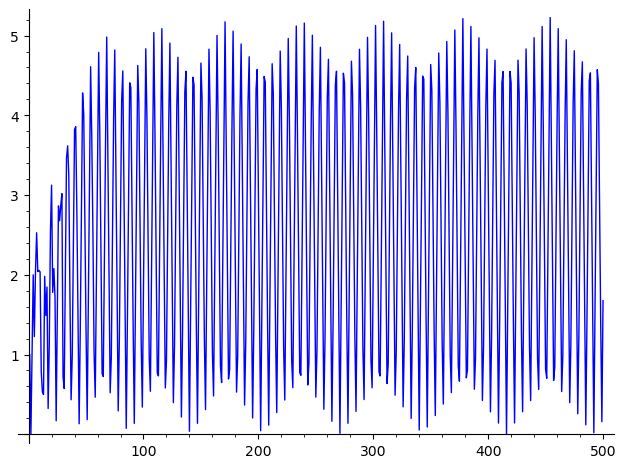

In [2]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(3580) 
h_list=[1]+[nth_prime(k+1)-nth_prime(k)-2 for k in range(1,501)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run16may26no1.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run16may26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run16may26no3.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run16may26no4.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run16may26no5.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)

In [1]:
import pickle
with open('/Users/barrybrent/data2/run16may26no4.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
with open('/Users/barrybrent/data2/run16may26no4a.txt', 'wb') as wfile:
    pickle.dump(mins_list[:100], wfile)
with open('/Users/barrybrent/data2/run16may26no4b.txt', 'wb') as wfile:
    pickle.dump(mins_list[101:200], wfile)
with open('/Users/barrybrent/data2/run16may26no4c.txt', 'wb') as wfile:
    pickle.dump(mins_list[201:300], wfile)
with open('/Users/barrybrent/data2/run16may26no4d.txt', 'wb') as wfile:
    pickle.dump(mins_list[301:400], wfile)
with open('/Users/barrybrent/data2/run16may26no4e.txt', 'wb') as wfile:
    pickle.dump(mins_list[401:500], wfile)

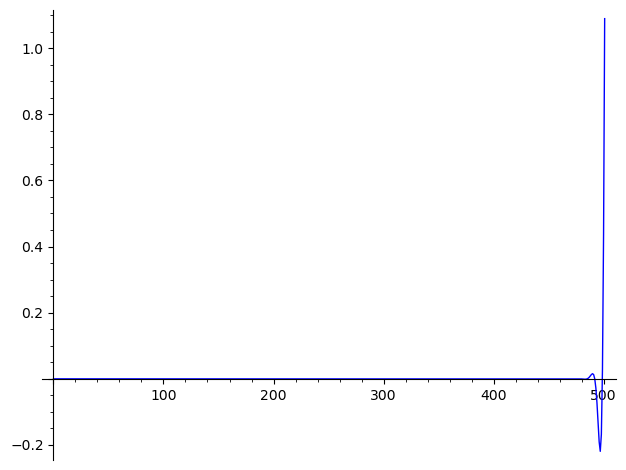

In [1]:
import pickle
with open('/Users/barrybrent/data2/run16may26no2.txt', 'rb') as rfile:
    deformed_h__list = pickle.load(rfile)
p = list_plot(deformed_h__list, plotjoined=True, axes_labels=['', ''])
p.show()

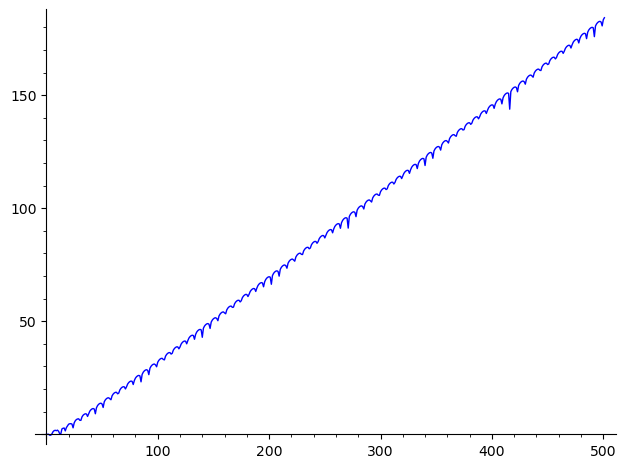

In [11]:
import pickle
with open('/Users/barrybrent/data2/run16may26no2.txt', 'rb') as rfile:
    deformed_h__list = pickle.load(rfile)
logplot=[]
for x in deformed_h__list:
    if x==0:
        logplot.append(0)
    if x>0:
        logplot.append(log(x))
    if x<0:
        logplot.append(log(-x))
        
p = list_plot(logplot, plotjoined=True, axes_labels=['', ''])
p.show()